In [1]:
# download dataset from Google Drive
import gdown
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import time
import warnings
warnings.filterwarnings("ignore")

file_id = "1plQQ4Sb3IduSsgcgnm3WYfkvjVkfyaw_"
url = f"https://drive.google.com/uc?id={file_id}"
filename = "dataset.csv"
gdown.download(url, filename, quiet=False)
print(f"Downloaded: {filename}")

Downloading...
From: https://drive.google.com/uc?id=1plQQ4Sb3IduSsgcgnm3WYfkvjVkfyaw_
To: /content/dataset.csv
100%|██████████| 2.46M/2.46M [00:00<00:00, 89.7MB/s]

Downloaded: dataset.csv


In [2]:
#reading of file

data = pd.read_csv(filename, index_col=False)

data = data.ffill() #
Y = data['outcome']        # outcome
X = data.drop('outcome',axis=1)    # features
df_one = pd.get_dummies(Y)
X_original=X;Y_original=Y
display(data)
print(data.groupby('outcome').size())


,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,outcome
0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
69995,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,22431,1,163,72.0,135,80,1,2,0,0,0,1


outcome
0    35021
1    34979
dtype: int64


In [3]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn import tree
X_train, X_test, Y_train, Y_test = train_test_split (X, Y, test_size = 0.30, random_state=21)
#model=AdaBoostClassifier(n_estimators=100, random_state=0)
model=tree.DecisionTreeClassifier()
model.fit(X_train, Y_train)

DecisionTreeClassifier()

Accuracy: 1.000
Sensitivity: 1.000
Specificity: 1.000


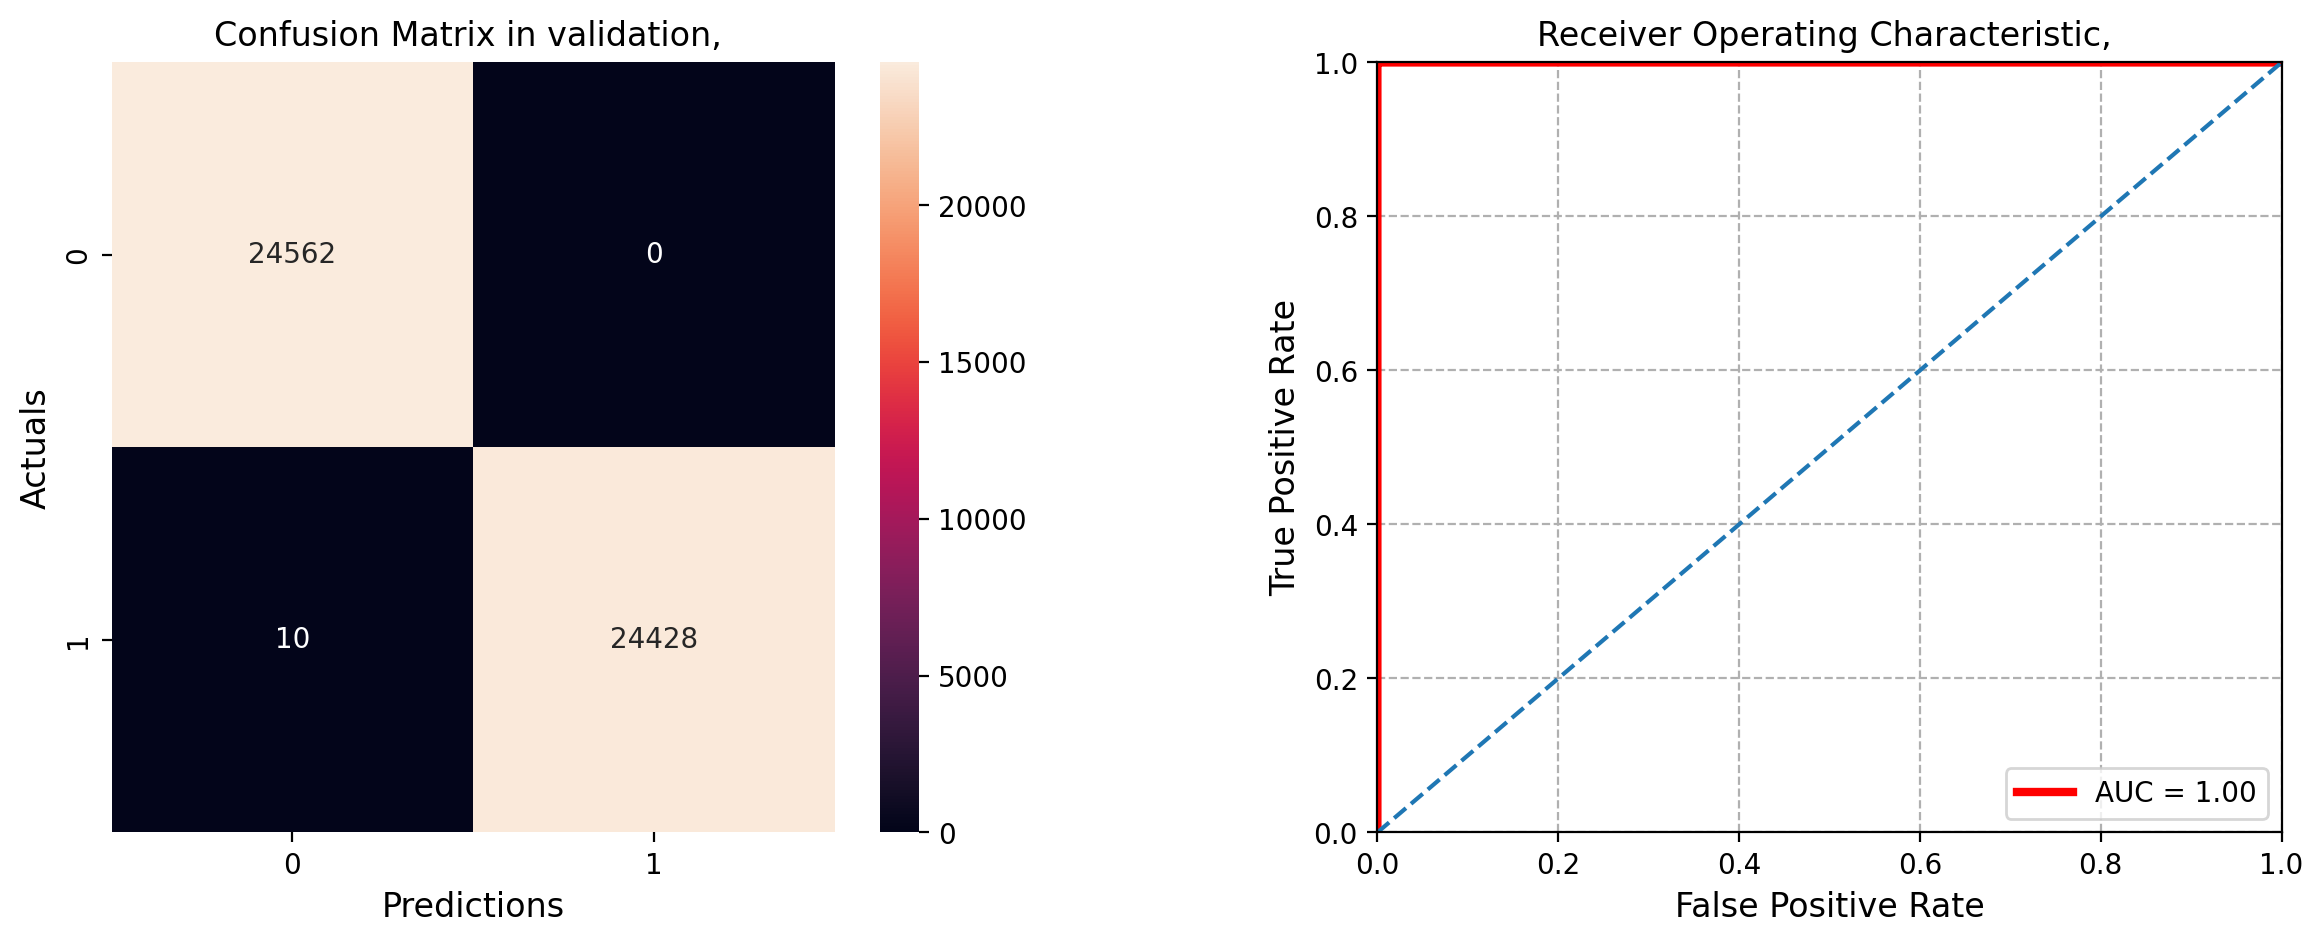

In [4]:
import seaborn as sns # for confusion matrix figures
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc, make_scorer # tools to evaluate  your model performance
com = confusion_matrix(Y_train, model.predict(X_train))
plt.figure(dpi=200,figsize=(14, 5));plt.subplot(1, 2, 1)
sns.heatmap(com,annot=True,fmt="d");plt.xlabel('Predictions', fontsize=12);plt.ylabel('Actuals', fontsize=12);plt.title('Confusion Matrix in validation, ', fontsize=12)
print('Accuracy: %.3f' % accuracy_score(Y_train, model.predict(X_train)));
print('Sensitivity: %.3f' % recall_score(Y_train, model.predict(X_train)));
print('Specificity: %.3f' % recall_score(Y_train, model.predict(X_train),pos_label=0))
false_positive_rate, true_positive_rate, thresholds = roc_curve(Y_train,model.predict_proba(X_train)[:,1]);roc_auc = auc(false_positive_rate, true_positive_rate)
plt.subplot(1, 2, 2);plt.title('Receiver Operating Characteristic, ',fontsize=12);plt.plot(false_positive_rate,true_positive_rate, color='red',label = 'AUC = %0.2f' % roc_auc,linewidth=3)
plt.legend(loc = 'lower right');plt.axis('tight');plt.ylabel('True Positive Rate', fontsize=12);plt.xlabel('False Positive Rate', fontsize=12)
plt.xlim([0, 1]);plt.ylim([0, 1]);plt.rc('font', family='serif');plt.rc('xtick', labelsize='small');plt.rc('ytick', labelsize='small');plt.plot([0, 1], [0, 1],linestyle='--')
plt.rcParams['figure.dpi']=100;plt.grid(linestyle='--');#fig.savefig("myImagePDF.pdf", format="pdf", bbox_inches="tight")
plt.subplots_adjust(wspace=0.4)
plt.show()

Accuracy: 0.637
Sensitivity: 0.629
Specificity: 0.645


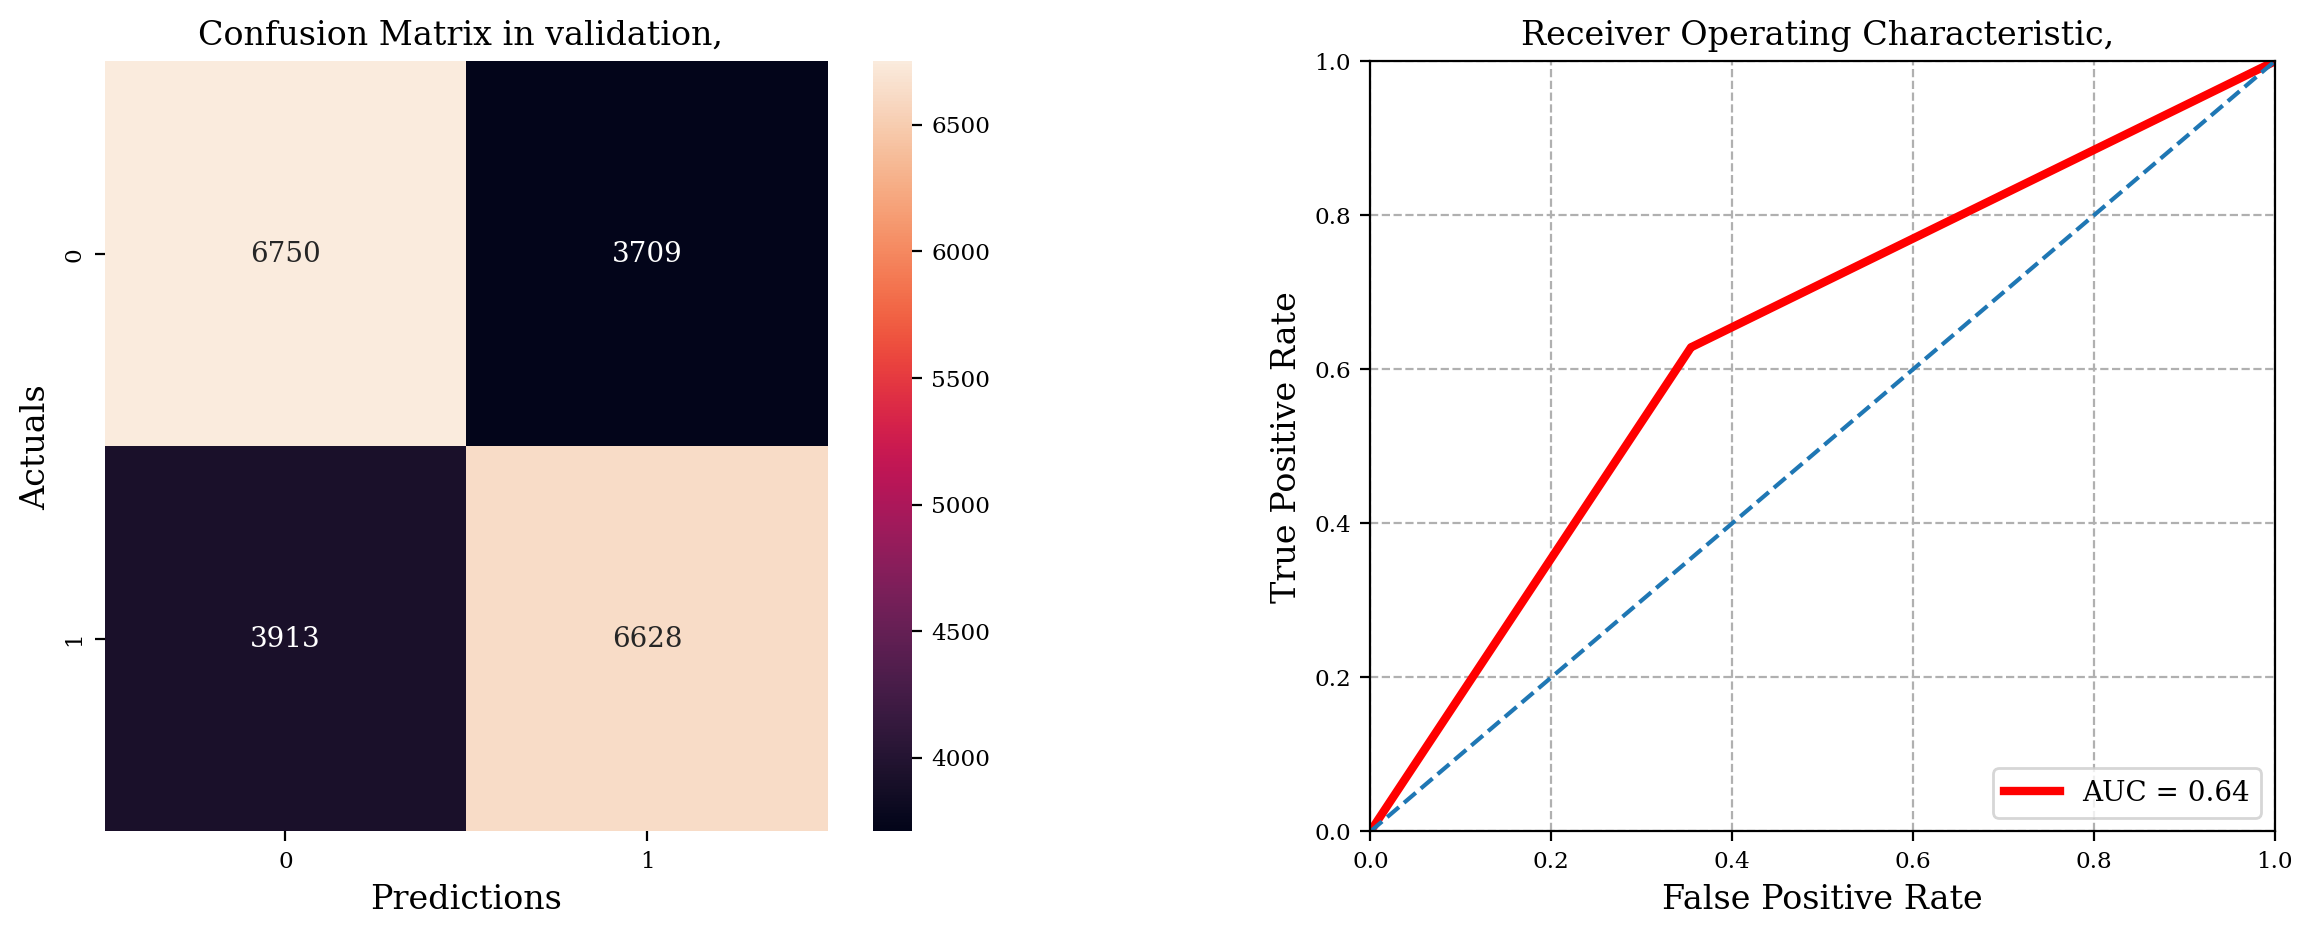

In [5]:
import seaborn as sns # for confusion matrix figures
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc, make_scorer # tools to evaluate  your model performance
com = confusion_matrix(Y_test, model.predict(X_test))
plt.figure(dpi=200,figsize=(14, 5));plt.subplot(1, 2, 1)
sns.heatmap(com,annot=True,fmt="d");plt.xlabel('Predictions', fontsize=12);plt.ylabel('Actuals', fontsize=12);plt.title('Confusion Matrix in validation, ', fontsize=12)
print('Accuracy: %.3f' % accuracy_score(Y_test, model.predict(X_test)));
print('Sensitivity: %.3f' % recall_score(Y_test, model.predict(X_test)));
print('Specificity: %.3f' % recall_score(Y_test, model.predict(X_test),pos_label=0))
false_positive_rate, true_positive_rate, thresholds = roc_curve(Y_test,model.predict_proba(X_test)[:,1]);roc_auc = auc(false_positive_rate, true_positive_rate)
plt.subplot(1, 2, 2);plt.title('Receiver Operating Characteristic, ',fontsize=12);plt.plot(false_positive_rate,true_positive_rate, color='red',label = 'AUC = %0.2f' % roc_auc,linewidth=3)
plt.legend(loc = 'lower right');plt.axis('tight');plt.ylabel('True Positive Rate', fontsize=12);plt.xlabel('False Positive Rate', fontsize=12)
plt.xlim([0, 1]);plt.ylim([0, 1]);plt.rc('font', family='serif');plt.rc('xtick', labelsize='small');plt.rc('ytick', labelsize='small');plt.plot([0, 1], [0, 1],linestyle='--')
plt.rcParams['figure.dpi']=100;plt.grid(linestyle='--');#fig.savefig("myImagePDF.pdf", format="pdf", bbox_inches="tight")
plt.subplots_adjust(wspace=0.4)
plt.show()

Accuracy: 0.634
Sensitivity: 0.632
Specificity: 0.635


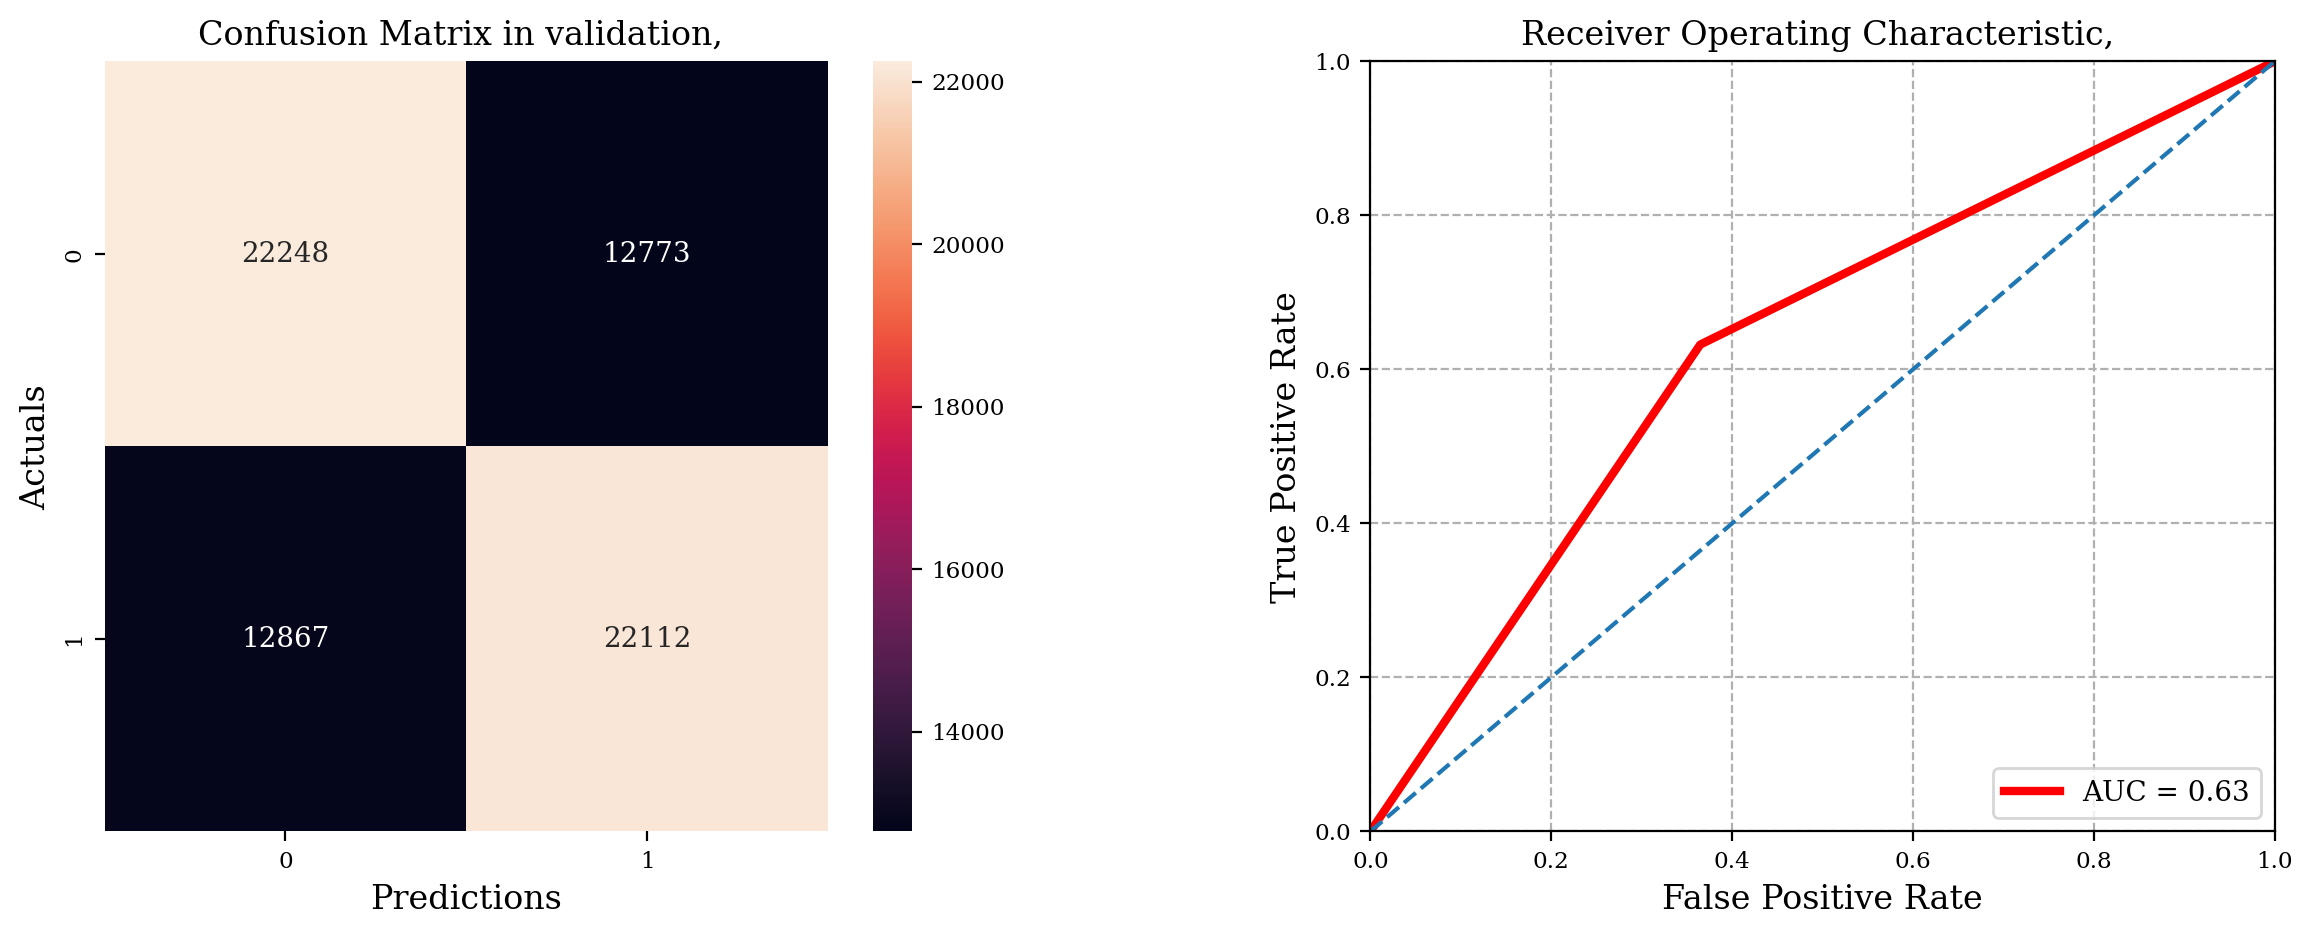

In [6]:
# The probabilities as in the original code sample
from sklearn.model_selection import cross_val_predict
Y_probCV = cross_val_predict(model, X, Y, cv=5, method='predict_proba')
y_sorted = np.unique(Y_probCV)
indices = np.argmax(Y_probCV, axis=1);y_predCV = y_sorted[indices]
import numpy as np
# Get a list of classes that matches the columns of `y_prob`

import seaborn as sns # for confusion matrix figures
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc, make_scorer # tools to evaluate  your model performance
com = confusion_matrix(Y, indices)
plt.figure(dpi=200,figsize=(14, 5));plt.subplot(1, 2, 1)
sns.heatmap(com,annot=True,fmt="d");plt.xlabel('Predictions', fontsize=12);plt.ylabel('Actuals', fontsize=12);plt.title('Confusion Matrix in validation, ', fontsize=12)
print('Accuracy: %.3f' % accuracy_score(Y, indices));
print('Sensitivity: %.3f' % recall_score(Y, indices));
print('Specificity: %.3f' % recall_score(Y, indices,pos_label=0))
false_positive_rate, true_positive_rate, thresholds = roc_curve(Y,Y_probCV[:,1]);roc_auc = auc(false_positive_rate, true_positive_rate)
plt.subplot(1, 2, 2);plt.title('Receiver Operating Characteristic, ',fontsize=12);plt.plot(false_positive_rate,true_positive_rate, color='red',label = 'AUC = %0.2f' % roc_auc,linewidth=3)
plt.legend(loc = 'lower right');plt.axis('tight');plt.ylabel('True Positive Rate', fontsize=12);plt.xlabel('False Positive Rate', fontsize=12)
plt.xlim([0, 1]);plt.ylim([0, 1]);plt.rc('font', family='serif');plt.rc('xtick', labelsize='small');plt.rc('ytick', labelsize='small');plt.plot([0, 1], [0, 1],linestyle='--')
plt.rcParams['figure.dpi']=100;plt.grid(linestyle='--');#fig.savefig("myImagePDF.pdf", format="pdf", bbox_inches="tight")
plt.subplots_adjust(wspace=0.4)
plt.show()

# Compare different machine learning models

CART: 0.632939 (0.007670) (run time: 3.389027)
NB: 0.584694 (0.006292) (run time: 0.207009)
KNN: 0.679816 (0.005339) (run time: 4.093168)
AdaB: 0.727347 (0.005356) (run time: 12.220833)
RF: 0.715735 (0.006704) (run time: 92.995159)


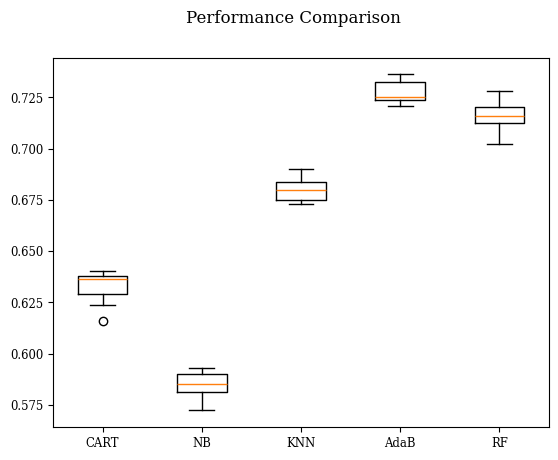

In [7]:
models_list = [];models_list.append(('CART', DecisionTreeClassifier()));models_list.append(('NB', GaussianNB()));models_list.append(('KNN', KNeighborsClassifier()));
models_list.append(('AdaB', AdaBoostClassifier()));models_list.append(('RF', RandomForestClassifier()))


num_folds = 10;results = [];names = []
for name, model in models_list:
    kfold = KFold(n_splits=num_folds)
    start = time.time()
    cv_results = cross_val_score(model, X_train, Y_train, cv=kfold, scoring='accuracy')
    end = time.time()
    results.append(cv_results)
    names.append(name)
    print( "%s: %f (%f) (run time: %f)" % (name, cv_results.mean(), cv_results.std(), end-start))
fig = plt.figure();fig.suptitle('Performance Comparison');ax = fig.add_subplot(111);plt.boxplot(results);ax.set_xticklabels(names);plt.show()


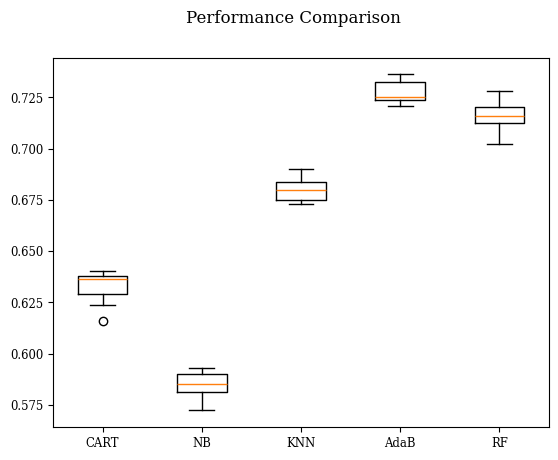

In [8]:
fig = plt.figure()
fig.suptitle('Performance Comparison')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()